# Recruit Restaurant Visitor Forecasting — 모델링

## 0. 환경 설정

In [30]:
!pip install shap

In [31]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
import shap
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)

## 1. 데이터 로드

- `train_master` : 정답(`visitors`) 포함 → **학습용**
- `test_master` : 정답 없음, 미래(4/23~5/31) → **예측 대상**
- `feature_candidates` : 모델 입력 피처 61개 목록

In [32]:
TRAIN_PATH = './pre_file/recruit_train_master_preprocessed_final.csv'
TEST_PATH  = './pre_file/recruit_test_master_preprocessed_final.csv'
FEAT_PATH  = './pre_file/recruit_model_feature_candidates_final.csv'

train = pd.read_csv(TRAIN_PATH, parse_dates=['visit_date'])
test  = pd.read_csv(TEST_PATH)
feats = pd.read_csv(FEAT_PATH)['feature'].tolist()
print('train', train.shape, '| test', test.shape, '| 피처', len(feats), '개')

train (252108, 72) | test (32019, 66) | 피처 61 개


## 2. 평가지표와 검증 설계

**RMSLE = log1p 공간의 RMSE.** 절대 오차가 아닌 **비율(%) 오차** 측정 → 작은 식당도 동일 비중
→ 타깃을 `log_visitors = log1p(visitors)` 로 학습, 예측은 `expm1` 로 복원

**검증은 시계열 분할 필수.** test가 미래이므로 검증셋도 train의 **마지막 약 39일**로 설정 → 동일한 미래 예측 상황 재현, 랜덤 분할은 미래 정보 누수로 점수 과대평가

In [36]:
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(np.clip(y_pred,0,None)) - np.log1p(y_true))**2))

VALID_START = '2017-03-15'                 # 마지막 약 39일 = 검증셋
tr = train[train['visit_date'] <  VALID_START].copy()
va = train[train['visit_date'] >= VALID_START].copy()
y_va = va['visitors'].values
print(f"학습 {len(tr):,}행 ({tr.visit_date.min().date()}~{tr.visit_date.max().date()})")
print(f"검증 {len(va):,}행 ({va.visit_date.min().date()}~{va.visit_date.max().date()})")

학습 224,077행 (2016-01-01~2017-03-14)
검증 28,031행 (2017-03-15~2017-04-22)


## 3. Baseline

전처리의 누수 없는 통계 피처를 그대로 예측값으로 사용 → 문제 난이도 측정

In [37]:
results = {}
results['전체 평균']         = rmsle(y_va, np.full(len(va), tr['visitors'].mean()))
results['식당별 평균']       = rmsle(y_va, va['store_prior_mean'])
results['식당×요일 평균']    = rmsle(y_va, va['store_dow_prior_mean'])
results['최근28일 이동평균'] = rmsle(y_va, va['rolling_28_mean'])
pd.Series(results, name='RMSLE').round(4).to_frame()

,RMSLE
전체 평균,0.8663
식당별 평균,0.6257
식당×요일 평균,0.5514
최근28일 이동평균,0.6107


> **결과**: `식당×요일 평균(≈0.55)` 이 최강 베이스라인 → 요일 패턴이 수요의 핵심 / 이후 ML이 넘어야 할 기준선

## 4. Ridge Regression

선형 모델 기준선 / 숫자 피처 표준화 + 저차원 범주(카테고리·지역·요일) 원핫 인코딩

In [38]:
cat_cols  = ['air_category_name','air_area_name','area_level_1','area_level_2','day_of_week']
num_cols  = [f for f in feats if f not in cat_cols]
ridge_cat = ['air_category_name','area_level_1','day_of_week']

pre = ColumnTransformer([('num', StandardScaler(), num_cols),
                         ('cat', OneHotEncoder(handle_unknown='ignore'), ridge_cat)])
ridge = Pipeline([('pre', pre), ('m', Ridge(alpha=10.0))])
ridge.fit(tr[num_cols+ridge_cat], tr['log_visitors'])
results['Ridge'] = rmsle(y_va, np.expm1(ridge.predict(va[num_cols+ridge_cat])))
print('Ridge RMSLE:', round(results['Ridge'], 4))

Ridge RMSLE: 0.5567


> 선형 모델은 베이스라인과 큰 차이 없음 → 수요엔 **피처 간 상호작용·비선형**이 많아 선형 표현 한계

## 5. LightGBM (메인 모델)

범주형 직접 처리, 타깃은 `log_visitors`, 검증셋으로 early stopping, 
추가로 **예약 피처 제거 모델**과 비교 → 예약 데이터의 실제 기여 검증

In [39]:
for c in cat_cols:
    tr[c] = tr[c].astype('category'); va[c] = va[c].astype('category')

params = dict(objective='regression_l2', metric='rmse', learning_rate=0.05, num_leaves=63,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
              min_child_samples=50, seed=42, verbose=-1)

dtr = lgb.Dataset(tr[feats], tr['log_visitors'], categorical_feature=cat_cols)
dva = lgb.Dataset(va[feats], np.log1p(y_va), categorical_feature=cat_cols, reference=dtr)
model = lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
results['LightGBM'] = rmsle(y_va, np.expm1(model.predict(va[feats], num_iteration=model.best_iteration)))
print('LightGBM RMSLE:', round(results['LightGBM'], 4), '| best_iter', model.best_iteration)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[924]	valid_0's rmse: 0.488277
LightGBM RMSLE: 0.4883 | best_iter 924


In [40]:
# 예약 피처 제거 모델 (예약 가치 검증)
res_feats = [f for f in feats if 'reserve' in f or 'lead_time' in f]
no_res    = [f for f in feats if f not in res_feats]
nr_cat    = [c for c in cat_cols if c in no_res]
m2 = lgb.train(params, lgb.Dataset(tr[no_res], tr['log_visitors'], categorical_feature=nr_cat),
               num_boost_round=2000,
               valid_sets=[lgb.Dataset(va[no_res], np.log1p(y_va), categorical_feature=nr_cat)],
               callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
results['LightGBM(예약X)'] = rmsle(y_va, np.expm1(m2.predict(va[no_res], num_iteration=m2.best_iteration)))
print('예약 제외 RMSLE:', round(results['LightGBM(예약X)'], 4))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[570]	valid_0's rmse: 0.504002
예약 제외 RMSLE: 0.504


In [41]:
print('=== 모델별 RMSLE (낮을수록 좋음) ===')
print(pd.Series(results, name='RMSLE').round(4).sort_values(ascending=False).to_string())

imp = pd.DataFrame({'feature':feats, 'gain':model.feature_importance('gain')}).sort_values('gain', ascending=False)
print('\n=== 중요도 TOP 12 ===')
print(imp.head(12).to_string(index=False))

=== 모델별 RMSLE (낮을수록 좋음) ===
전체 평균            0.8663
식당별 평균           0.6257
최근28일 이동평균       0.6107
Ridge            0.5567
식당×요일 평균         0.5514
LightGBM(예약X)    0.5040
LightGBM         0.4883

=== 중요도 TOP 12 ===
                   feature          gain
      store_dow_prior_mean 523893.671918
           rolling_28_mean  87448.155360
             air_area_name  40548.230011
            rolling_7_mean  30089.122742
           rolling_14_mean  29502.575448
total_reserve_visitors_sum  13397.554169
                   dow_num  10605.501690
          store_prior_mean  10542.618646
            rolling_28_std  10064.499974
               day_of_week   8958.361910
             rolling_7_std   8400.885010
            rolling_14_std   8332.935893


> **핵심 결과**
> - LightGBM ≈ **0.49** → 최고 베이스라인(0.55) 대비 **약 11% 개선**
> - 예약 피처 제거 시 **0.49 → 0.50 악화** → *예약 데이터가 정확도를 높임*
> - 중요도: `식당×요일 평균` 압도적, 이어서 `rolling 평균`(최근 추세), `지역`, `예약 인원`

## 6. SHAP — 예측 근거 해석

예측값을 피처별 기여도로 분해

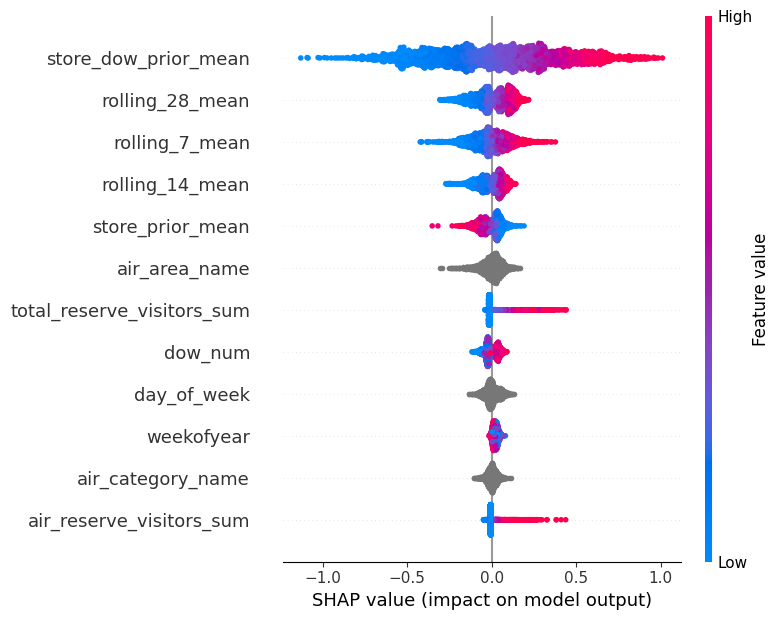

In [42]:
samp = va.sample(3000, random_state=0)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(samp[feats])
shap.summary_plot(shap_values, samp[feats], max_display=12, show=True)

In [43]:
shap_imp = pd.DataFrame({'feature':feats, 'mean_abs_shap':np.abs(shap_values).mean(0)}) \
             .sort_values('mean_abs_shap', ascending=False)
print('=== SHAP 중요도 TOP 10 ===')
print(shap_imp.head(10).to_string(index=False))

=== SHAP 중요도 TOP 10 ===
                   feature  mean_abs_shap
      store_dow_prior_mean       0.320121
           rolling_28_mean       0.086685
            rolling_7_mean       0.084454
           rolling_14_mean       0.058596
          store_prior_mean       0.050731
             air_area_name       0.040298
total_reserve_visitors_sum       0.039533
                   dow_num       0.033789
               day_of_week       0.029900
                weekofyear       0.022353


> **해석
> 1. **피크일을 높게 예측한 근거** → 높은 `식당×요일 평균` + `rolling 평균` 상승 + `예약 인원` 증가
> 2. **저수요일을 낮게 예측한 근거** → 낮은 요일 평균·낮은 rolling·특정 지역/요일 패턴
> 3. **예약 데이터 기여 여부** → 기여함 (ablation에서 RMSLE 개선, SHAP 상위 기여)
> 4. **점주의 사전 대비 가능 시점** → `D-3/D-7 예약` 피처 기여 → 최소 **3~7일 전** 수요 감지 가능

## 7. 비즈니스 KPI — 피크/저수요 예측 편향

전처리의 **공식 플래그**(`peak_candidate_flg`, `low_demand_candidate_flg`)로 구간별 예측 편향 측정, 
RMSLE 최적화 모델이 운영상 남기는 위험 확인

In [44]:
va['pred'] = np.expm1(model.predict(va[feats]))
va['err']  = va['pred'] - va['visitors']          # + 과대예측 / - 과소예측

rows = []
for name, flag in [('피크일','peak_candidate_flg'), ('저수요일','low_demand_candidate_flg')]:
    s = va[va[flag] == 1]
    rows.append({'구간':name, '건수':len(s), '실제평균':round(s['visitors'].mean(),1),
                 '예측평균':round(s['pred'].mean(),1), '평균오차':round(s['err'].mean(),1)})
normal = va[(va['peak_candidate_flg']==0) & (va['low_demand_candidate_flg']==0)]
rows.insert(1, {'구간':'보통','건수':len(normal),'실제평균':round(normal['visitors'].mean(),1),
                '예측평균':round(normal['pred'].mean(),1),'평균오차':round(normal['err'].mean(),1)})
pd.DataFrame(rows)

,구간,건수,실제평균,예측평균,평균오차
0,피크일,8483,33.2,22.5,-10.7
1,보통,9966,24.3,23.4,-1.0
2,저수요일,9582,10.2,16.0,5.8


> **운영 인사이트**
> - **피크일 과소예측** → 인력·재고 **부족 위험** ⚠️
> - **저수요일 과대예측** → 과잉 발주·과잉 근무 **낭비 위험**
> - 보통 날은 거의 정확 → 모델은 평균엔 강하나 **극단값 평탄화**(RMSLE 모델의 전형적 특성)
> - **제안**: 피크 가능일에 안전마진(+α) 적용으로 결품 위험 완화

## 8. 최종 제출 파일 생성

검증 설정 그대로 **전체 train** 재학습 → test 예측 → `expm1` 복원 → 음수 클리핑 → 저장

In [45]:
for c in cat_cols:
    train[c] = train[c].astype('category')
    test[c]  = pd.Categorical(test[c], categories=train[c].cat.categories)   # 카테고리 정렬 일치

final = lgb.train(params, lgb.Dataset(train[feats], train['log_visitors'], categorical_feature=cat_cols),
                  num_boost_round=int(model.best_iteration * 1.1))           # 검증 best_iter 기준
pred = np.clip(np.expm1(final.predict(test[feats])), 0, None)

submission = pd.DataFrame({'id':test['id'], 'visitors':pred})
submission.to_csv('submission_lgbm.csv', index=False)
print('제출 파일 저장: submission_lgbm.csv', submission.shape)
submission.head()

제출 파일 저장: submission_lgbm.csv (32019, 2)


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,3.297309
1,air_00a91d42b08b08d9_2017-04-24,20.703806
2,air_00a91d42b08b08d9_2017-04-25,24.140866
3,air_00a91d42b08b08d9_2017-04-26,29.357838
4,air_00a91d42b08b08d9_2017-04-27,30.714768


## 정리 — 모델 선택 이유 & 결론 &핵심 인사이트

> 식당별 일일 방문자 수를 예측하는 과제,
> 단순한 모델에서 정교한 모델 순으로 단계적 비교

### 1) 모델 선택 이유

**① 단순 평균 (Baseline) — 최소 성능 기준선**
"식당×요일별 평균 방문자 수"로 예측하는 가장 단순한 방식
복잡한 모델이 이 수준을 넘지 못하면 도입 의미가 없으므로, 성능 비교의 출발점으로 설정

**② Ridge (선형 회귀) — 선형 모델의 한계 점검**
여러 변수를 하나의 선형식으로 합산해 예측하는 기본 통계 모델
성능이 단순 평균과 거의 동일 → 방문자 수가 변수의 단순 합으로는 설명되지 않음을 확인

**③ LightGBM (메인 모델) — 변수 간 상호작용 포착**
"금요일 + 공휴일 전날 + 특정 지역·업종"처럼 여러 조건이 결합된 패턴을 자동으로 학습하는 트리 기반 모델
실제 수요가 조건들의 복합 작용으로 결정되는 구조를 가장 잘 반영하므로 메인 모델로 채택

**④ SHAP — 예측 근거 해석 도구**
각 예측값이 어떤 변수의 영향으로 산출됐는지 정량적으로 분해하는 해석 기법
단순 예측기를 넘어 "근거를 설명할 수 있는 모델"로 만들기 위해 도입

### 2) 결론 — 모델별 성능

점수(RMSLE)는 낮을수록 정확

| 모델 | 점수 | 해석 |
|---|---|---|
| 단순 평균(식당×요일) | 0.55 | 요일 패턴만으로도 상당한 설명력 |
| Ridge | 0.56 | 단순 평균 대비 개선 없음 |
| **LightGBM** | **0.49** | **최고 성능, 기준선 대비 약 11% 개선** |

예약 변수를 제거하면 0.49 → 0.50 으로 성능 하락
→ 예약 데이터가 예측 정확도에 실질적으로 기여함을 입증

### 3) 핵심 인사이트

**① 예측의 핵심 축은 "과거 요일별 수요"**
해당 식당이 특정 요일에 받아온 평균 방문자 수가 가장 강력한 예측 단서

**② 최근 추세와 예약 신호가 정확도를 보강**
직전 기간의 방문 추세(rolling)와 누적 예약량이 기준 수요에 더해지며 정확도 향상

**③ 예약 데이터는 운영 가치로 직결**
예약은 통상 방문 3~7일 전에 발생 → 점주가 사전에 수요를 파악해 인력·재고를 준비할 수 있는 선행 지표

**④ 모델의 구조적 약점 — 평균 회귀 경향**
피크일은 과소예측(−10.8명), 저수요일은 과대예측(+5.8명)하는 편향 존재
→ 피크 예상일에 안전 마진을 더하는 운영 규칙을 병행할 때 실효성 보완
